📊 Exploratory Data Analysis (EDA) in Python

STEP 1: Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

STEP 2: Load Cleaned Data

In [5]:
customers = pd.read_csv("D:\\SQL\\EDA SQL Project\\Python\\clean_dim_customers.csv")
products = pd.read_csv("D:\\SQL\\EDA SQL Project\\Python\\clean_dim_products.csv")
sales = pd.read_csv("D:\\SQL\\EDA SQL Project\\Python\\clean_fact_sales.csv")


STEP 3: Basic Dataset Overview

In [6]:
print("Customers Shape:", customers.shape)
print("Products Shape:", products.shape)
print("Sales Shape:", sales.shape)

Customers Shape: (18484, 11)
Products Shape: (295, 11)
Sales Shape: (60398, 11)


In [7]:
print(customers.describe(include="all"))
print(products.describe(include="all"))
print(sales.describe())

        customer_key   customer_id customer_number first_name last_name  \
count   18484.000000  18484.000000           18484      18484     18484   
unique           NaN           NaN           18484        670       375   
top              NaN           NaN      AW00011000  Katherine      Diaz   
freq             NaN           NaN               1         97       209   
mean     9242.500000  20241.500000             NaN        NaN       NaN   
std      5336.015523   5336.015523             NaN        NaN       NaN   
min         1.000000  11000.000000             NaN        NaN       NaN   
25%      4621.750000  15620.750000             NaN        NaN       NaN   
50%      9242.500000  20241.500000             NaN        NaN       NaN   
75%     13863.250000  24862.250000             NaN        NaN       NaN   
max     18484.000000  29483.000000             NaN        NaN       NaN   

              country marital_status gender   birthdate create_date  \
count           18484       

STEP 4: Missing Value Analysis


In [8]:
print(customers.isnull().sum())
print(products.isnull().sum())
print(sales.isnull().sum())

customer_key        0
customer_id         0
customer_number     0
first_name          0
last_name           0
country             0
marital_status      0
gender              0
birthdate          17
create_date         0
customer_name       0
dtype: int64
product_key       0
product_id        0
product_number    0
product_name      0
category_id       0
category          0
subcategory       0
maintenance       0
cost              0
product_line      0
start_date        0
dtype: int64
order_number      0
product_key       0
customer_key      0
order_date       19
shipping_date     0
due_date          0
sales_amount      0
quantity          0
price             0
order_year       19
order_month      19
dtype: int64


STEP 5: Customer Analysis

In [9]:
# Customers by country
customers_by_country = customers["country"].value_counts()

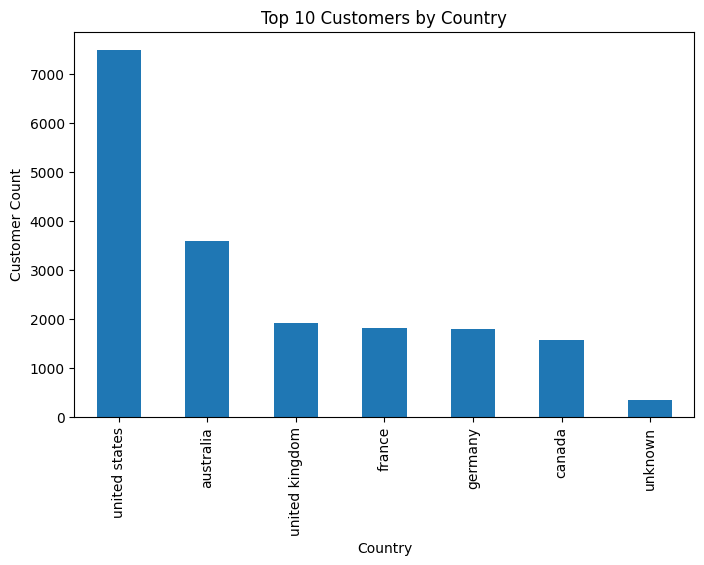

In [10]:
plt.figure(figsize=(8,5))
customers_by_country.head(10).plot(kind="bar")
plt.title("Top 10 Customers by Country")
plt.xlabel("Country")
plt.ylabel("Customer Count")
plt.show()

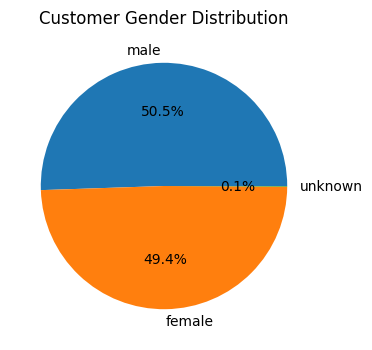

In [11]:
# Gender distribution
plt.figure(figsize=(6,4))
customers["gender"].value_counts().plot(kind="pie", autopct="%1.1f%%")
plt.title("Customer Gender Distribution")
plt.ylabel("")
plt.show()

STEP 6: Product Analysis

In [12]:
# Products by category
products_by_category = products["category"].value_counts()


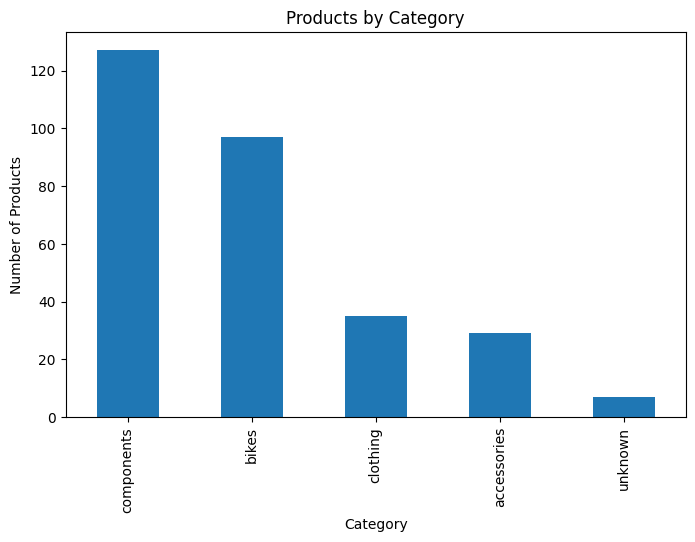

In [13]:

plt.figure(figsize=(8,5))
products_by_category.plot(kind="bar")
plt.title("Products by Category")
plt.xlabel("Category")
plt.ylabel("Number of Products")
plt.show()

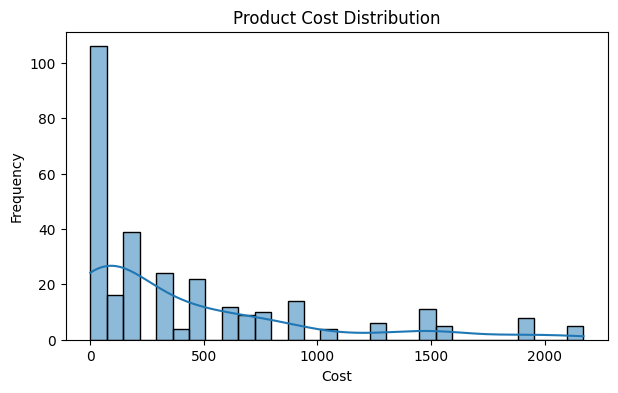

In [14]:
# Product cost distribution
plt.figure(figsize=(7,4))
sns.histplot(products["cost"], bins=30, kde=True)
plt.title("Product Cost Distribution")
plt.xlabel("Cost")
plt.ylabel("Frequency")
plt.show()

STEP 7: Sales Analysis

In [15]:
#Total sales by year
sales_by_year = sales.groupby("order_year")["sales_amount"].sum()

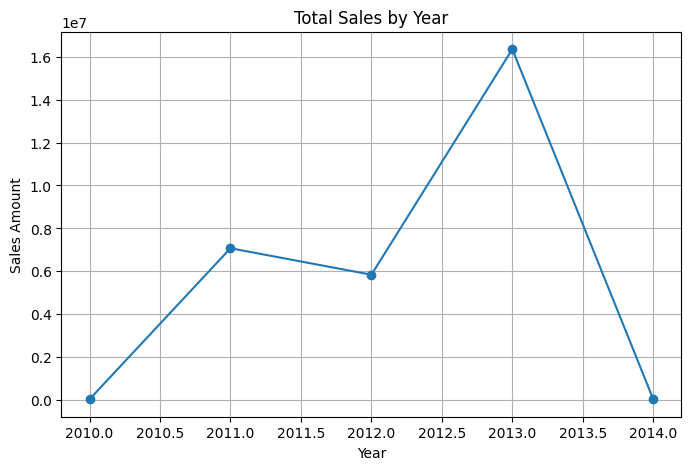

In [16]:
plt.figure(figsize=(8,5))
sales_by_year.plot(marker="o")
plt.title("Total Sales by Year")
plt.xlabel("Year")
plt.ylabel("Sales Amount")
plt.grid(True)
plt.show()

In [17]:
# Sales by month
sales_by_month = sales.groupby("order_month")["sales_amount"].sum()

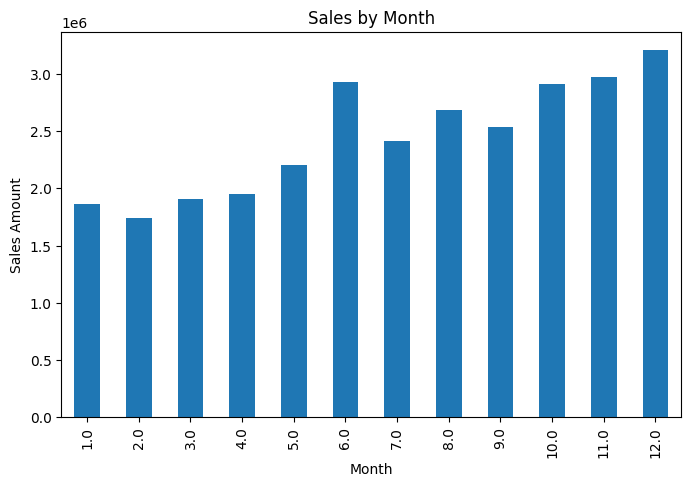

In [18]:
plt.figure(figsize=(8,5))
sales_by_month.plot(kind="bar")
plt.title("Sales by Month")
plt.xlabel("Month")
plt.ylabel("Sales Amount")
plt.show()


STEP 8: Top Products & Customers

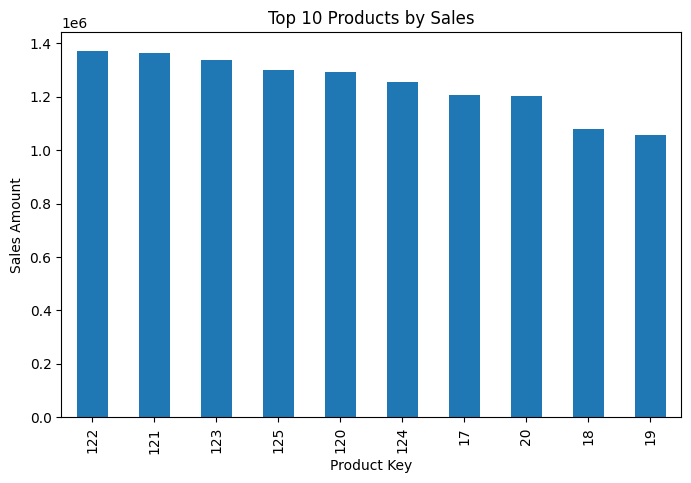

In [20]:
# Top 10 products by sales
top_products = (
    sales.groupby("product_key")["sales_amount"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(8,5))
top_products.plot(kind="bar")
plt.title("Top 10 Products by Sales")
plt.xlabel("Product Key")
plt.ylabel("Sales Amount")
plt.show()

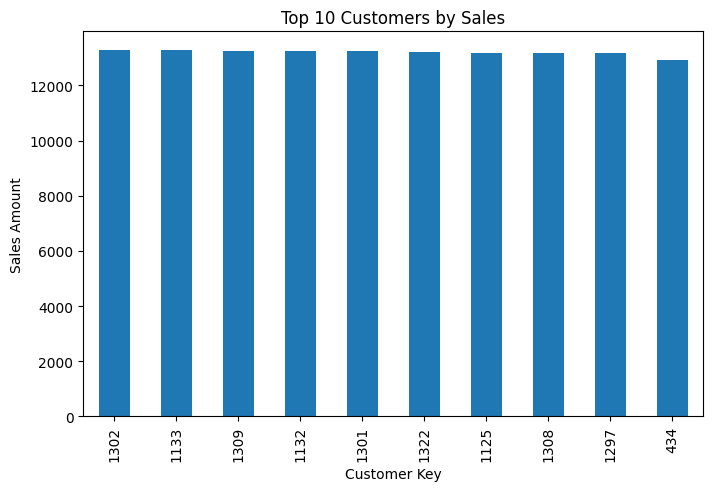

In [22]:
# Top 10 customers by sales
top_customers = (
    sales.groupby("customer_key")["sales_amount"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(8,5))
top_customers.plot(kind="bar")
plt.title("Top 10 Customers by Sales")
plt.xlabel("Customer Key")
plt.ylabel("Sales Amount")
plt.show()

 STEP 9: Correlation Analysis

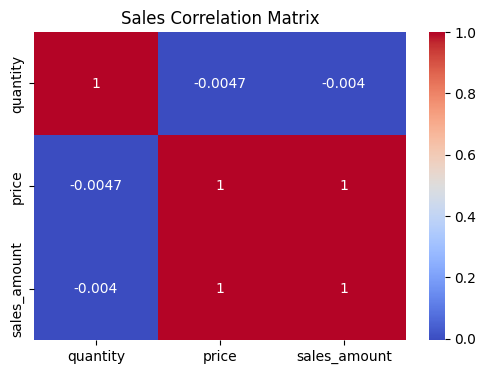

In [23]:
plt.figure(figsize=(6,4))
sns.heatmap(
    sales[["quantity", "price", "sales_amount"]].corr(),
    annot=True,
    cmap="coolwarm"
)
plt.title("Sales Correlation Matrix")
plt.show()

STEP 10: Key Business Insights (Printed)

In [24]:
print("Total Revenue:", sales["sales_amount"].sum())
print("Average Order Value:", sales["sales_amount"].mean())
print("Total Orders:", sales["order_number"].nunique())

Total Revenue: 29356250.0
Average Order Value: 486.04672340143713
Total Orders: 27659


EDA 11: Customer Age Distribution

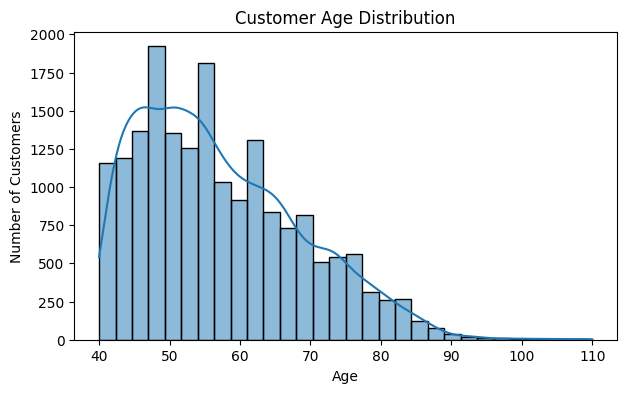

In [25]:
from datetime import datetime

current_year = datetime.now().year
customers["age"] = current_year - pd.to_datetime(customers["birthdate"]).dt.year

plt.figure(figsize=(7,4))
sns.histplot(customers["age"].dropna(), bins=30, kde=True)
plt.title("Customer Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Customers")
plt.show()

EDA 12: Sales by Product Category

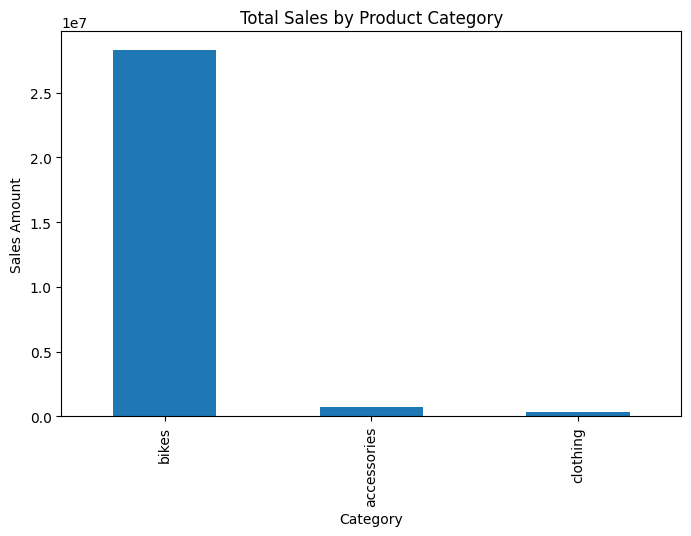

In [26]:
sales_product = sales.merge(
    products[["product_key", "category"]],
    on="product_key",
    how="left"
)

category_sales = sales_product.groupby("category")["sales_amount"].sum()

plt.figure(figsize=(8,5))
category_sales.sort_values(ascending=False).plot(kind="bar")
plt.title("Total Sales by Product Category")
plt.xlabel("Category")
plt.ylabel("Sales Amount")
plt.show()

EDA 13: Sales by Customer Country

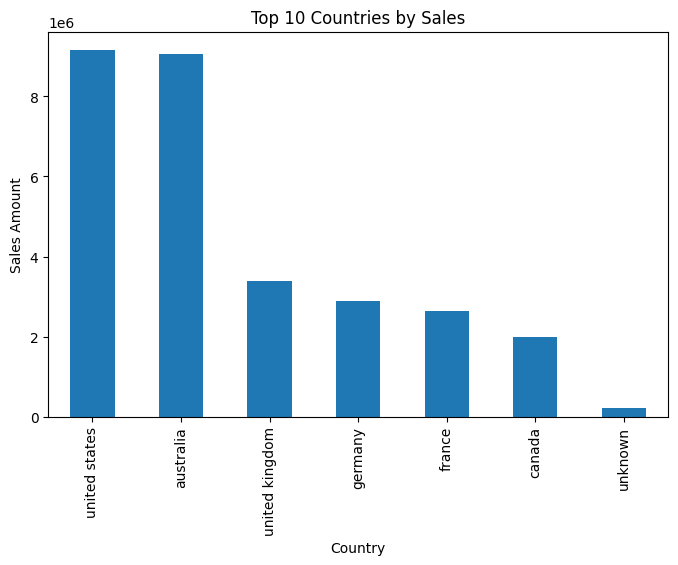

In [27]:
sales_customer = sales.merge(
    customers[["customer_key", "country"]],
    on="customer_key",
    how="left"
)

country_sales = sales_customer.groupby("country")["sales_amount"].sum()

plt.figure(figsize=(8,5))
country_sales.sort_values(ascending=False).head(10).plot(kind="bar")
plt.title("Top 10 Countries by Sales")
plt.xlabel("Country")
plt.ylabel("Sales Amount")
plt.show()

EDA 14: Order Frequency per Customer

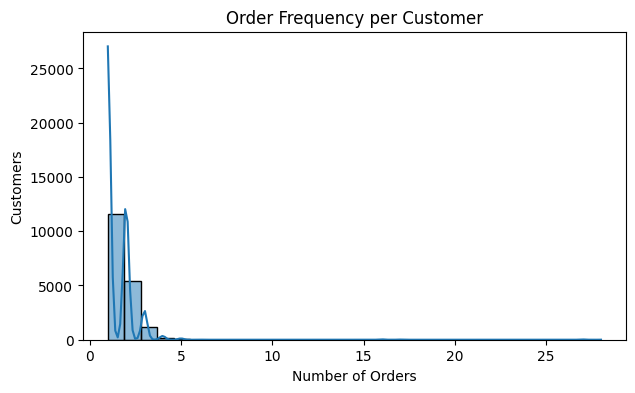

In [28]:
orders_per_customer = sales.groupby("customer_key")["order_number"].nunique()

plt.figure(figsize=(7,4))
sns.histplot(orders_per_customer, bins=30, kde=True)
plt.title("Order Frequency per Customer")
plt.xlabel("Number of Orders")
plt.ylabel("Customers")
plt.show()